In [46]:
%pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [47]:
%pip install scikit-optimize

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [48]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score, recall_score, precision_score


from scikeras.wrappers import KerasClassifier

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [49]:
train = "../datasets/Updated/final_train.csv"
test = "../datasets/Updated/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [50]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(np.unique(y_encoded))

print("Number of classes:", num_classes)

Number of classes: 4


In [51]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

Train shape: (151470, 136, 1)
Test shape: (51569, 136, 1)


In [53]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    min_delta=1e-3
)

In [54]:
def build_cnn(filters=64,kernel_size=3,dense_units=128,dropout=0.5,lr=0.001):

    
    model = Sequential([

        Conv1D(filters,kernel_size,padding="same",activation="relu",input_shape=(X.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 2,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 4,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        GlobalAveragePooling1D(),

        Dense(dense_units, activation="relu"),

        Dropout(dropout),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
   

In [55]:
cnn_model = KerasClassifier(
    model=build_cnn,
    verbose=0,
)

In [56]:
search_spaces = {
    "model__filters": Integer(32, 128),
    "model__dense_units": Integer(64, 256),
    "model__dropout": Real(0.1, 0.5),
    "model__kernel_size": Integer(3, 7),
    "model__lr": Real(1e-5, 1e-2, prior="log-uniform"),
    "batch_size": Integer(16, 64),
    
    
}

In [60]:
bayes_search = BayesSearchCV(
    estimator=cnn_model,
    search_spaces=search_spaces,
    n_iter=5,
    cv=10,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=10,
    random_state=42
)

bayes_search.fit(X, y_encoded, callbacks=[early_stop], validation_split=0.1, epochs=20)



print("\nBest parameters:", bayes_search.best_params_)
print("Best CV score:", bayes_search.best_score_)


Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV 1/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 1/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=1.000 total time= 8.1min
[CV 2/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 2/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=1.000 total time= 8.0min
[CV 3/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


...

[CV 9/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.972 total time=11.2min
[CV 10/10; 1/1] START batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 10/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.972 total time=11.1min


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best parameters: OrderedDict({'batch_size': 54, 'model__dense_units': 148, 'model__dropout': 0.31064809485107703, 'model__filters': 101, 'model__kernel_size': 7, 'model__lr': 0.0014160984697405585})
Best CV score: 0.9516848332062638


In [ ]:
best_params = bayes_search.best_params_

final_model = build_cnn(
    filters=best_params["model__filters"],
    kernel_size=best_params["model__kernel_size"],
    dense_units=best_params["model__dense_units"],
    dropout=best_params["model__dropout"],
    lr=best_params["model__lr"],
    
)

history = final_model.fit(
    X,
    y_encoded,
    callbacks=[early_stop],
    verbose=1
    epochs=50
)

best_epoch = np.argmin(history["val_loss"]) + 1
print("Best epoch:", best_epoch)



TypeError: build_cnn() got an unexpected keyword argument 'epochs'

In [ ]:

train_predictions = final_model.predict(X)
test_predictions = final_model.predict(X_test)

train_predicted_classes = np.argmax(train_predictions, axis=1)
test_predicted_classes = np.argmax(test_predictions, axis=1)

4734/4734 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1612/1612 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [ ]:
predictions = final_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(y_test_encoded, predicted_classes)
f1 = f1_score(y_test_encoded, predicted_classes, average="weighted")

print("\nTest Accuracy:", accuracy)
print("Test F1 Score:", f1)

1612/1612 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Test Accuracy: 0.9402160212530783
Test F1 Score: 0.9359889257822395


In [ ]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        predicted_classes,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(y_test_encoded, predicted_classes)

print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))


Classification Report:
                   precision    recall  f1-score   support

Credential Access       1.00      1.00      1.00      8699
        Discovery       0.86      0.99      0.92     13430
   Reconnaissance       0.57      0.31      0.40      2037
             none       0.99      0.94      0.96     27403

         accuracy                           0.94     51569
        macro avg       0.85      0.81      0.82     51569
     weighted avg       0.94      0.94      0.94     51569


False Positive Rate (per class)
Credential Access: 0.0000
Discovery: 0.0582
Reconnaissance: 0.0095
none: 0.0163

Average FPR: 0.020987635462277308


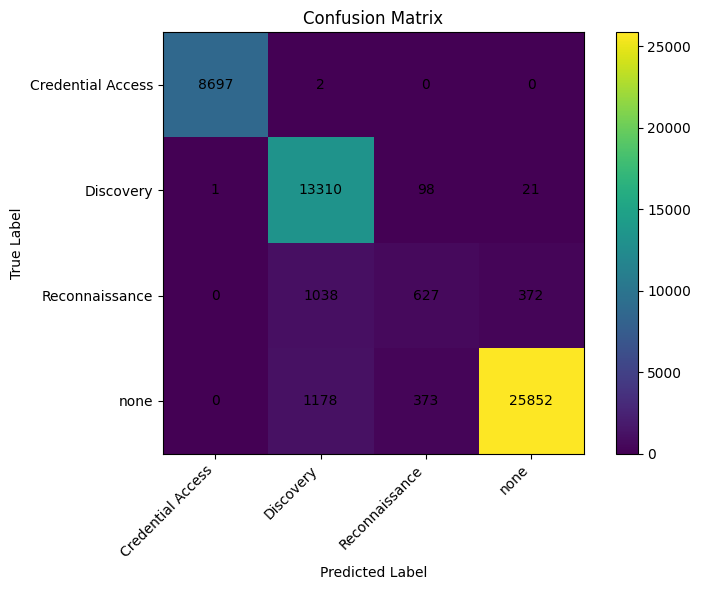

In [ ]:
cm = confusion_matrix(y_test_encoded, predicted_classes)

class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

1612/1612 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


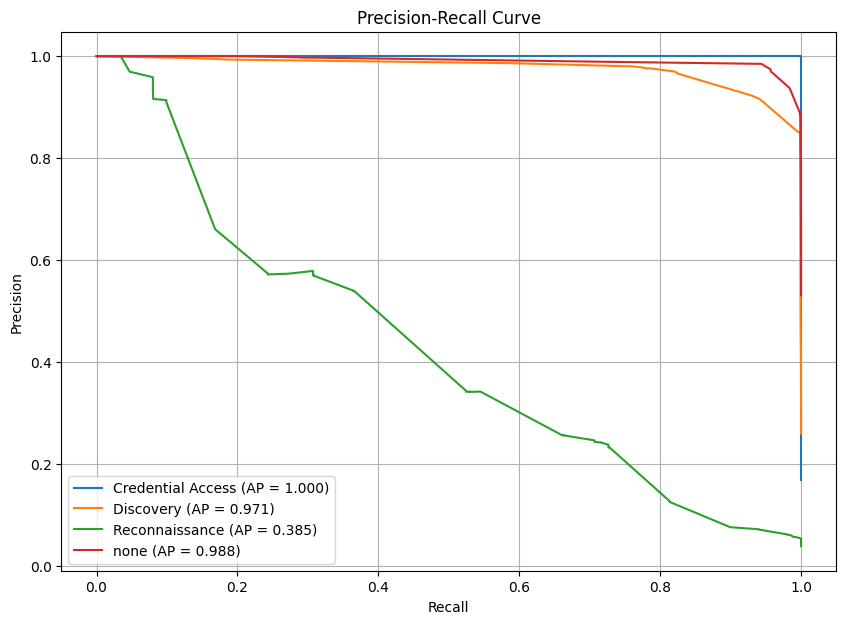

In [ ]:


y_pred_proba = final_model.predict(X_test)

y_test_bin = label_binarize(
    y_test_encoded,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(label_encoder.classes_):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.grid(True)
plt.show()

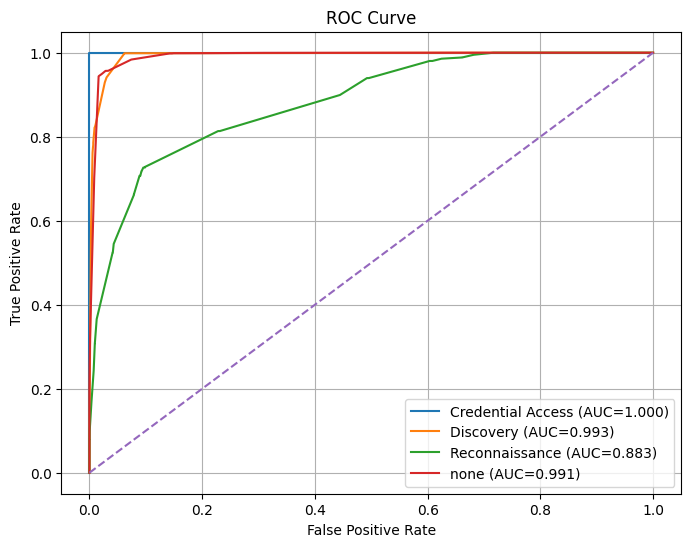

In [ ]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8, 6))

for i, label in enumerate(label_encoder.classes_):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

metrics = []

for i, class_name in enumerate(label_encoder.classes_):

    # ROC metrics
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    roc_auc = auc(fpr, tpr)

  
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    metrics.append({
        "Class": class_name,
        "ROC AUC": round(roc_auc, 4),
        "Precision-Recall": round(ap, 4)
    })

metrics_df = pd.DataFrame(metrics)


metrics_df = metrics_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

print(metrics_df)

               Class  ROC AUC  Precision-Recall
0  Credential Access   1.0000            1.0000
1          Discovery   0.9927            0.9707
2               none   0.9914            0.9882
3     Reconnaissance   0.8831            0.3851


In [ ]:
def weighted_fpr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    fprs = []

    for i in range(len(cm)):
        FP = cm[:, i].sum() - cm[i, i]
        TN = cm.sum() - (
            cm[i, :].sum()
            + cm[:, i].sum()
            - cm[i, i]
        )

        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        fprs.append(fpr)

    return np.mean(fprs)

In [ ]:
results = {
    "Dataset": ["Training", "Test"],
    "Accuracy": [
        accuracy_score(y_encoded, train_predicted_classes),
        accuracy_score(y_test_encoded, test_predicted_classes)
    ],
    "Precision (Weighted)": [
        precision_score(y_encoded, train_predicted_classes,
                        average="weighted", zero_division=0),
        precision_score(y_test_encoded, test_predicted_classes,
                        average="weighted", zero_division=0)
    ],
    "Recall (Weighted)": [
        recall_score(y_encoded, train_predicted_classes,
                     average="weighted"),
        recall_score(y_test_encoded, test_predicted_classes,
                     average="weighted")
    ],
    "F1 (Weighted)": [
        f1_score(y_encoded, train_predicted_classes,
                 average="weighted"),
        f1_score(y_test_encoded, test_predicted_classes,
                 average="weighted")
    ],
    "FPR": [
        weighted_fpr(y_encoded, train_predicted_classes),
        weighted_fpr(y_test_encoded, test_predicted_classes)
    ]
}

results_df = pd.DataFrame(results)

print("\nCNN Performance Summary")
print(results_df.round(4).to_string(index=False))


#print("Epoch:", best_epoch)
print("\nBest parameters:", bayes_search.best_params_)
print("Best CV score:", bayes_search.best_score_)



print("\nGeneralization Gap (Train - Test)")

metrics = [
    ("Accuracy",
     accuracy_score(y_encoded, train_predicted_classes),
     accuracy_score(y_test_encoded, test_predicted_classes)),

    ("Precision",
     precision_score(y_encoded, train_predicted_classes,
                     average="weighted", zero_division=0),
     precision_score(y_test_encoded, test_predicted_classes,
                     average="weighted", zero_division=0)),

    ("Recall",
     recall_score(y_encoded, train_predicted_classes,
                  average="weighted"),
     recall_score(y_test_encoded, test_predicted_classes,
                  average="weighted")),

    ("F1",
     f1_score(y_encoded, train_predicted_classes,
              average="weighted"),
     f1_score(y_test_encoded, test_predicted_classes,
              average="weighted")),

    ("FPR",
     weighted_fpr(y_encoded, train_predicted_classes),
     weighted_fpr(y_test_encoded, test_predicted_classes))
]

for name, train_val, test_val in metrics:
    print(f"{name}: {(train_val - test_val):.4f}")


CNN Performance Summary
 Dataset  Accuracy  Precision (Weighted)  Recall (Weighted)  F1 (Weighted)    FPR
Training    0.9388                0.9334             0.9388         0.9314 0.0228
    Test    0.9402                0.9379             0.9402         0.9360 0.0210

Best parameters: OrderedDict({'batch_size': 36, 'model__dense_units': 204, 'model__dropout': 0.47314719953913353, 'model__filters': 62, 'model__kernel_size': 6, 'model__lr': 0.00017472534129202037})
Best CV score: 0.9316429979263441

Generalization Gap (Train - Test)
Accuracy: -0.0014
Precision: -0.0045
Recall: -0.0014
F1: -0.0046
FPR: 0.0018
